In [2]:
from llama_cpp import Llama
from llama_cpp.llama_chat_format import MiniCPMv26ChatHandler

chat_handler = MiniCPMv26ChatHandler.from_pretrained(
    repo_id="openbmb/MiniCPM-V-2_6-gguf",
    filename="*mmproj*",
)
# Load the vision-language model with the handler
llm = Llama.from_pretrained(
    repo_id="openbmb/MiniCPM-V-2_6-gguf",
    filename="ggml-model-Q4_1.gguf",
    chat_handler=chat_handler,
    n_gpu_layers=10,
    n_ctx=2048,
)

ggml_metal_init: allocating
ggml_metal_init: found device: Apple M2
ggml_metal_init: picking default device: Apple M2
ggml_metal_load_library: using embedded metal library
ggml_metal_init: GPU name:   Apple M2
ggml_metal_init: GPU family: MTLGPUFamilyApple8  (1008)
ggml_metal_init: GPU family: MTLGPUFamilyCommon3 (3003)
ggml_metal_init: GPU family: MTLGPUFamilyMetal3  (5001)
ggml_metal_init: simdgroup reduction   = true
ggml_metal_init: simdgroup matrix mul. = true
ggml_metal_init: has residency sets    = true
ggml_metal_init: has bfloat            = true
ggml_metal_init: use bfloat            = false
ggml_metal_init: hasUnifiedMemory      = true
ggml_metal_init: recommendedMaxWorkingSetSize  =  5726.63 MB
ggml_metal_init: loaded kernel_add                                    0x106e596f0 | th_max = 1024 | th_width =   32
ggml_metal_init: loaded kernel_add_row                                0x106e59b50 | th_max = 1024 | th_width =   32
ggml_metal_init: loaded kernel_sub                  

In [5]:
import base64

def image_to_readable(path):
    with open(path, "rb") as f:
        encoded_image = base64.b64encode(f.read()).decode("utf-8")
        data_url = f"data:image/jpeg;base64,{encoded_image}"
    return data_url
    

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
's in this image?<|im_end|>
<|im_start|>assistant

Llama.generate: 344 prefix-match hit, remaining 1 prompt tokens to eval
llama_perf_context_print:        load time =    6627.59 ms
llama_perf_context_print: prompt eval time =   79111.06 ms /   346 tokens (  228.64 ms per token,     4.37 tokens per second)
llama_perf_context_print:        eval time =  304103.20 ms /    48 runs   ( 6335.48 ms per token,     0.16 tokens per second)
llama_perf_context_print:       total time =  310846.30 ms /   394 tokens

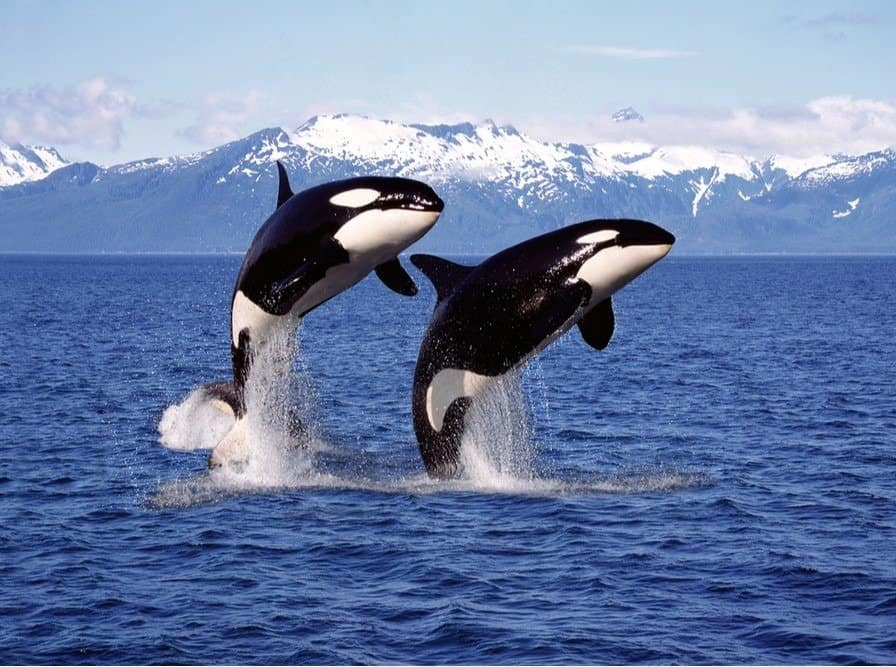

383.416335105896


In [6]:
import time
start=time.time()
image=image_to_readable("/Users/admin/Desktop/Projects/scrammbled/animal.jpg")
response = llm.create_chat_completion(
    messages = [
        {
            "role": "user",
            "content": [
                {"type" : "text", "text": "What's in this image?"},
                {"type": "image_url", "image_url": {"url": image } }

            ]
        }
    ]
)
end=time.time()
print(end-start)



In [15]:
summary=response['choices'][0]['message']['content']

In [12]:
llm_text = Llama.from_pretrained(
	repo_id="MaziyarPanahi/Meta-Llama-3-8B-Instruct-GGUF",
	filename="Meta-Llama-3-8B-Instruct.Q4_K_M.gguf",
    n_ctx=4096,
    n_gpu_layers=10
)

llama_model_load_from_file_impl: using device Metal (Apple M2) - 2785 MiB free
llama_model_loader: loaded meta data with 22 key-value pairs and 291 tensors from /Users/admin/.cache/huggingface/hub/models--MaziyarPanahi--Meta-Llama-3-8B-Instruct-GGUF/snapshots/4ece958b356f2ec00338e5898ba0a7254d976baf/./Meta-Llama-3-8B-Instruct.Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = hub
llama_model_loader: - kv   2:                           llama.vocab_size u32              = 128256
llama_model_loader: - kv   3:                       llama.context_length u32              = 8192
llama_model_loader: - kv   4:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   5:                   

In [17]:

    file_prompt =  f"""Based on the summary below, generate a specific and descriptive filename that captures the essence of the document.
    Limit the filename to a maximum of 3 words. Use nouns and avoid starting with verbs like 'depicts', 'shows', 'presents', etc.
    Do not include any data type words like 'text', 'document', 'pdf', etc. Use only letters and connect words with underscores.

    Summary: {summary}

    Examples:
    1. Summary: A research paper on the fundamentals of string theory.
        Filename: fundamentals_of_string_theory

    2. Summary: An article discussing the effects of climate change on polar bears.
        Filename: climate_change_polar_bears

    Now generate the filename.

    Output only the filename, without any additional text.

    Filename:"""
    completion_filename=llm_text.create_chat_completion(
        messages=[
            {
                "role": "user",
                "content": f"{file_prompt}"
            }
        ],
    )
    filename=completion_filename['choices'][0]['message']['content'].strip()

    #foldername
    folder_prompt=f"""Using the summary below, identify a broad category or theme that best represents the main topic of the document.
    - This will be used as a folder name.
    - Limit the category to 1 or 2 words.
    - Use only nouns—do not use verbs or phrases starting with action words.
    - Avoid specific details, words from the filename, or generic terms like 'untitled' or 'unknown'.
    Summary: {summary}
    Examples:
    1. Summary: A historical overview of the French Revolution and its global impact.
       Category: history
    2. Summary: A paper examining artificial intelligence applications in modern healthcare.
       Category: technology
    Now generate the category.
    Return only the category name with no extra text.
    Category:"""

    completion_foldername=llm_text.create_chat_completion(
        messages=[
            {
                "role": "user",
                "content": f"{folder_prompt}"
            }
        ],
    )
    foldername=completion_foldername['choices'][0]['message']['content'].strip()

Llama.generate: 235 prefix-match hit, remaining 1 prompt tokens to eval
llama_perf_context_print:        load time =   18186.98 ms
llama_perf_context_print: prompt eval time =       0.00 ms /     1 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =   41883.13 ms /     6 runs   ( 6980.52 ms per token,     0.14 tokens per second)
llama_perf_context_print:       total time =   41920.85 ms /     7 tokens
Llama.generate: 6 prefix-match hit, remaining 209 prompt tokens to eval
llama_perf_context_print:        load time =   18186.98 ms
llama_perf_context_print: prompt eval time =   14476.54 ms /   209 tokens (   69.27 ms per token,    14.44 tokens per second)
llama_perf_context_print:        eval time =   13047.09 ms /     2 runs   ( 6523.55 ms per token,     0.15 tokens per second)
llama_perf_context_print:       total time =   27549.58 ms /   211 tokens


In [19]:
print(f"filename:{filename} foldername:{foldername}")

filename:orcas_blue_mountains foldername:Marine
